# Прогноз CTR для Advandex

Пётр Дудочкин 01.05.26

## План работы

**Цель:** Разработать надёжную модель бинарной классификации, которая предсказывает вероятность клика (CTR) на рекламное объявление.

**Задачи:**
1. Подготовить среду и загрузить необходимые данный.
1. Провести исследовательский анализ данных, обработать пропущенные значения и выбросы.
1. Разделить данные на выборки.
1. Провести предобработку данных.
1. Провести отбор признаков.
1. Обучить базовую модель.
1. Оптимизировать модель за счёт подбора гиперпараметров.
1. Обучить финальную модель.
1. Откалибровать финальную модель и оценить качество калибровки.
1. Сделать отчёт о проделанной работе.
1. Сохранить модель для продакшена.

## Подготовка среды и загрузка данных

In [1]:
!pip install phik -q 
!pip install category_encoders -q 
!pip install mlxtend -q 
!pip install joblib -q

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from phik import report
from phik.report import plot_correlation_matrix

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV, cross_val_score

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer, TargetEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier

from sklearn.metrics import make_scorer, average_precision_score, brier_score_loss, precision_score, recall_score, f1_score

from sklearn.calibration import calibration_curve, CalibratedClassifierCV

import joblib

from sklearn.feature_selection import mutual_info_classif
from sklearn.svm import SVC
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold, RFE
from time import time

In [3]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

In [4]:
!pip freeze > requirements.txt
print("Зависимости сохранены в файл 'requirements.txt'")

Зависимости сохранены в файл 'requirements.txt'


In [5]:
RANDOM_STATE = 0
RANDOM_SEED = 0
np.random.seed(RANDOM_SEED)

In [6]:
df_original = pd.read_csv('ds_s16_ad_click_dataset.csv', decimal=".")
df = df_original.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                50000 non-null  float64
 1   click             50000 non-null  int64  
 2   hour              50000 non-null  int64  
 3   C1                50000 non-null  int64  
 4   banner_pos        50000 non-null  int64  
 5   site_id           50000 non-null  object 
 6   site_domain       50000 non-null  object 
 7   site_category     50000 non-null  object 
 8   app_id            50000 non-null  object 
 9   app_domain        50000 non-null  object 
 10  app_category      50000 non-null  object 
 11  device_id         50000 non-null  object 
 12  device_ip         50000 non-null  object 
 13  device_model      50000 non-null  object 
 14  device_type       50000 non-null  int64  
 15  device_conn_type  50000 non-null  int64  
 16  C14               50000 non-null  int64 

In [7]:
with pd.option_context('display.max_columns', None):
    display(df)

,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,app_category,device_id,device_ip,device_model,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21,ml_feature_1,ml_feature_2,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_7,ml_feature_8,ml_feature_9,ml_feature_10
0,1.005263e+19,1,14102100,1005,1,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,07d7df22,a99f214a,488a9a3e,31025cda,1,0,17614,320,50,1993,2,1063,-1,33,-0.996823,A,0.666588,0,0.817292,0.993275,Z,-0.619959,0.433666,0.274038
1,1.010597e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,75bb1b58,2ee63ff8,1,0,15701,320,50,1722,0,35,-1,79,-0.391309,C,5.146789,1,-0.883865,-0.825722,X,0.576526,-0.318558,-0.132851
2,1.012048e+19,0,14102100,1005,0,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,07d7df22,a99f214a,285263b0,d780319b,1,0,17914,320,50,2043,2,39,100084,32,-2.112732,D,7.169348,0,-0.859440,-0.338365,Y,-0.440047,-0.345412,0.340487
3,1.021995e+18,0,14102100,1005,0,85f751fd,c4e18dd6,50e219e0,39cfef32,d9b5648e,0f2161f8,a99f214a,18190986,f4fffcd0,1,0,21611,320,50,2480,3,297,100111,61,0.332707,A,-0.290708,1,0.062795,0.062934,Y,0.551982,0.733382,-0.198542
4,1.023455e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,b66e5482,a0f5f879,1,0,15702,320,50,1722,0,35,100084,79,1.166623,A,6.319134,1,-0.675276,0.797144,X,0.640827,0.297955,-0.136909
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,9.452834e+18,1,14103023,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,ff2e1365,edead9f4,1,0,22676,320,50,2616,0,35,100084,51,2.471707,A,6.971072,0,0.598654,0.897131,Y,1.102908,-0.063549,0.164935
49996,9.487581e+18,0,14103023,1005,1,0a742914,510bd839,f028772b,ecad2386,7801e8d9,07d7df22,a99f214a,43a81428,76dc4769,1,0,23723,320,50,2716,3,47,100188,23,0.380915,E,-1.829184,1,0.156171,0.181065,Y,0.136576,0.279587,0.193894
49997,9.895353e+18,0,14103023,1005,0,85f751fd,c4e18dd6,50e219e0,d36838b1,0e8616ad,0f2161f8,a99f214a,eb5b11d4,6db7d068,1,0,23866,320,50,2736,0,33,100172,246,0.582656,E,-1.839117,1,-0.358271,0.472134,Z,0.385089,-0.094572,0.123317
49998,9.911007e+17,0,14103023,1005,0,85f751fd,c4e18dd6,50e219e0,3c4b944d,2347f47a,0f2161f8,abc4029d,865aa73d,7ed3c15f,1,0,18987,320,50,2158,3,291,100189,61,-0.502279,B,4.263653,1,-1.567715,-0.997265,Z,-0.314288,0.267059,0.407779


## Исследовательский анализ данных (EDA)

In [8]:
df.nunique()

id                  50000
click                   2
hour                  240
C1                      7
banner_pos              7
site_id              1160
site_domain          1013
site_category          18
app_id                976
app_domain             67
app_category           22
device_id            8580
device_ip           41455
device_model         2521
device_type             4
device_conn_type        4
C14                  1497
C15                     8
C16                     9
C17                   387
C18                     4
C19                    64
C20                   149
C21                    59
ml_feature_1        50000
ml_feature_2            5
ml_feature_3        50000
ml_feature_4            2
ml_feature_5        50000
ml_feature_6        50000
ml_feature_7            3
ml_feature_8        50000
ml_feature_9        50000
ml_feature_10       50000
dtype: int64

В датасете содержится 50000 объектов и 34 признака. Признаки представлены числовым и категориальным типами данных.\
Данные не содержат полных дубликатов - число уникальных значений многих признаков совпадает с числом строк.

**Данные содержат следующие признаки:**

*Идентификаторы и временные метки:*\
`id` — уникальный идентификатор записи о показе баннера;\
`hour` — час, в который был показан баннер, в формате YYMMDDHH.

*Характеристики рекламной площадки (Site):*\
`site_id` — идентификатор веб-сайта, на котором был показан баннер;\
`site_domain` — домен веб-сайта;\
`site_category` — тематическая категория веб-сайта.

*Характеристики рекламируемого приложения (App):*\
`app_id` — идентификатор рекламируемого мобильного приложения;\
`app_domain` — домен рекламируемого приложения;\
`app_category` — категория рекламируемого приложения.

*Характеристики устройства и соединения пользователя:*\
`device_id` — идентификатор браузера или устройства;\
`device_ip` — IP-адрес устройства;\
`device_model` — модель устройства;\
`device_type` — тип устройства пользователя;\
`device_conn_type` — тип сетевого соединения устройства.

*Характеристики рекламного баннера и аукциона:*\
`C1` — анонимизированный признак, характеризующий контекст показа;\
`banner_pos` — позиция баннера на веб-странице;\
`C14 — C21` — группа анонимизированных признаков, описывающих параметры баннера, пользователя или аукциона.

*Машинно-сгенерированные признаки (ML Features):*\
`ml_feature_1, ml_feature_3 — ml_feature_6, ml_feature_8 — ml_feature_10` — числовые признаки, полученные в результате предварительной обработки и генерации новых признаков;\
`ml_feature_2, ml_feature_7` — категориальные признаки, полученные в результате предварительной обработки и генерации новых признаков.

*Целевая переменная:*\
`click` — бинарный признак, указывающий, был ли совершён клик по баннеру. 1 — клик был, 0 — клика не было.

In [9]:
print(df['click'].describe())
print()
print(df['click'].value_counts())

count    50000.000000
mean         0.172060
std          0.377436
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: click, dtype: float64

click
0    41397
1     8603
Name: count, dtype: int64


В целевой переменной `click` наблюдается дисбаланс классов - доля рекламы, на которую кликнули, составляет 17% от общего числа показов. В целевой переменной нет пропусков.

In [10]:
result = df.groupby('site_id')['site_domain'].nunique().reset_index()
result.columns = ['site_id', 'unique_domains_count']
result_sorted = result.sort_values('unique_domains_count', ascending=False)
print(result_sorted)

result2 = df.groupby('site_domain')['site_id'].nunique().reset_index()
result2.columns = ['site_domain', 'unique_ids_count']
result_sorted2 = result2.sort_values('unique_ids_count', ascending=False)
print(f'\n', '='*50, f'\n', result_sorted2)

       site_id  unique_domains_count
953   d1a51189                    18
617   887a4754                    11
887   c54454a2                    10
189   2c4ed2f7                     7
86    15941585                     7
...        ...                   ...
422   57fe1b20                     1
423   586f5b14                     1
424   5921638e                     1
425   5a156514                     1
1159  ffcff165                     1

[1160 rows x 2 columns]

      site_domain  unique_ids_count
778     c4e18dd6               203
28      08facbad                57
101     1e0acfb4                53
499     7e091613                 8
662     a434fa42                 8
...          ...               ...
363     5ecf85c2                 1
366     5f45e0ad                 1
368     603097a9                 1
369     6087b30a                 1
1012    fff32e94                 1

[1013 rows x 2 columns]


Исходя из описания, признак `app_id` и `id` искусственные, их можно исключить.\
\
Признак `device_ip` кодирует страну, регион и город, где находится устройство, а также используемого интернет-провайдера. При небольшом количестве пользователей он мог бы дать дополнительную информацию, но в нашем случае при количестве уникальных записей, сопостовимом с общим числом строк, высокой вероятностью использования динамического IP-адреса, а также при наличии признака `device_id`, определяющего конкретное устройство, признак  `device_ip` принимаем избыточным, его также можно исключить.\
\
Признаки `site_id` и `site_domain` в паре должны идентифицировать один и тот же веб-сайт (в редких случаях, при изменении домена, одному значению `site_id` может соответствовать несколько значений `site_domain`), но в датасете как одному идентификатору веб-сайта соответсвуют до 18 доменов, так и одному домену - до 203 идентификаторов. Возможно, разные страницы одного сайта могут при одном домене могут иметь разные идентификаторы. Эти признаки явно сильно коррелируют между собой.

Удалим технические и идентификационные признаки, которые обладают высокой уникальностью и не несут обобщаемой информации для модели:\
`app_id`, `id`, `device_id`, `device_ip`, `site_id`.

Признак `hour` не является непрерывным числовым признаком - это категория, которой может соответствовать некоторая вероятность клика, при этом зависимость от номера часа отсутствует. Для сокращения пространства признаков объединим часы в более крупные категории по времени суток. Также извлечём из признака `hour` информацию о дне недели.

In [11]:
df['hour_of_day'] = df['hour'] % 100
df['day_of_week'] = pd.to_datetime(df['hour'], format='%y%m%d%H').dt.dayofweek

def times_of_day(hour):
    if 5 <= hour < 11:
        return 'morning'
    elif 11 <= hour < 18:
        return 'day'
    elif 18 <= hour < 23:
        return 'evening'
    else:
        return 'night'
        
df['times_of_day'] = df['hour_of_day'].apply(times_of_day)

df = df.drop(columns=[])

In [12]:
# Исходя из типа данных, описания и количества уникальных значений, разобьём признаки на группы: числовые и категориальные,
# а также вынесем в отдельный список признаки для удаления.
all_features = df.columns.tolist()
features_to_drop = ['app_id', 'id', 'device_id', 'device_ip', 'site_id', 'hour', 'hour_of_day']

cat_features = ['click', 'C1', 'banner_pos', 'site_category', 'site_domain',
                'app_domain', 'app_category', 'device_model', 'device_type', 'device_conn_type',
                'ml_feature_2', 'ml_feature_7', 'times_of_day', 'day_of_week']

num_features = [f for f in all_features if f not in cat_features and f not in features_to_drop]

print(f'Категориальные признаки: {cat_features}\n')
print(f'Числовые признаки: {num_features}\n')
print(f'Признаки для удаления: {features_to_drop}')

Категориальные признаки: ['click', 'C1', 'banner_pos', 'site_category', 'site_domain', 'app_domain', 'app_category', 'device_model', 'device_type', 'device_conn_type', 'ml_feature_2', 'ml_feature_7', 'times_of_day', 'day_of_week']

Числовые признаки: ['C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'ml_feature_1', 'ml_feature_3', 'ml_feature_4', 'ml_feature_5', 'ml_feature_6', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10']

Признаки для удаления: ['app_id', 'id', 'device_id', 'device_ip', 'site_id', 'hour', 'hour_of_day']


In [13]:
# Изучим датасет на наличие квази-константных признаков.
# Квази-константные числовые признаки:
threshold = 0.1
vs_quasi = VarianceThreshold(threshold=threshold)
numerical_data = df[num_features]
vs_quasi.fit(numerical_data)
quasi_num_cols = [col for col, keep in zip(num_features, vs_quasi.get_support()) if not keep]
print(quasi_num_cols)

['ml_feature_10']


In [14]:
# Проведём ручную проверку через долю уникальных значений.
for col in num_features:
    most_frequent_ratio = df[col].value_counts().iloc[0] / len(df)
    if most_frequent_ratio > 0.9:
        print(f"{col}: {most_frequent_ratio:.2%} значений = {df[col].value_counts().index[0]}")

C15: 93.57% значений = 320
C16: 94.57% значений = 50


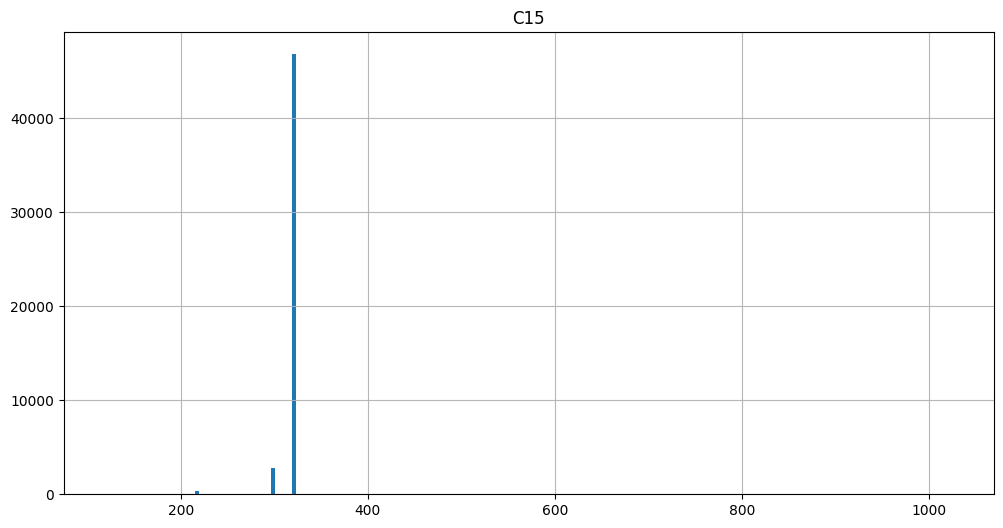

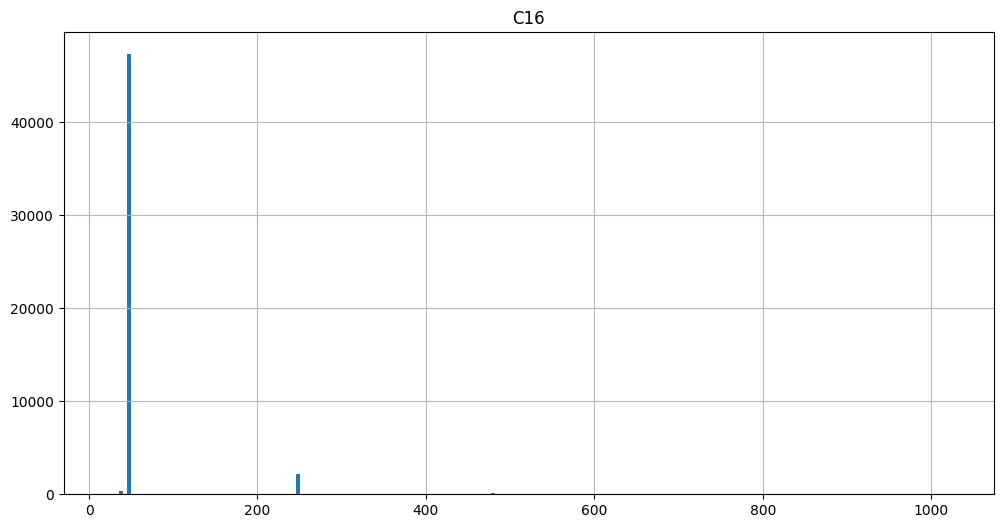

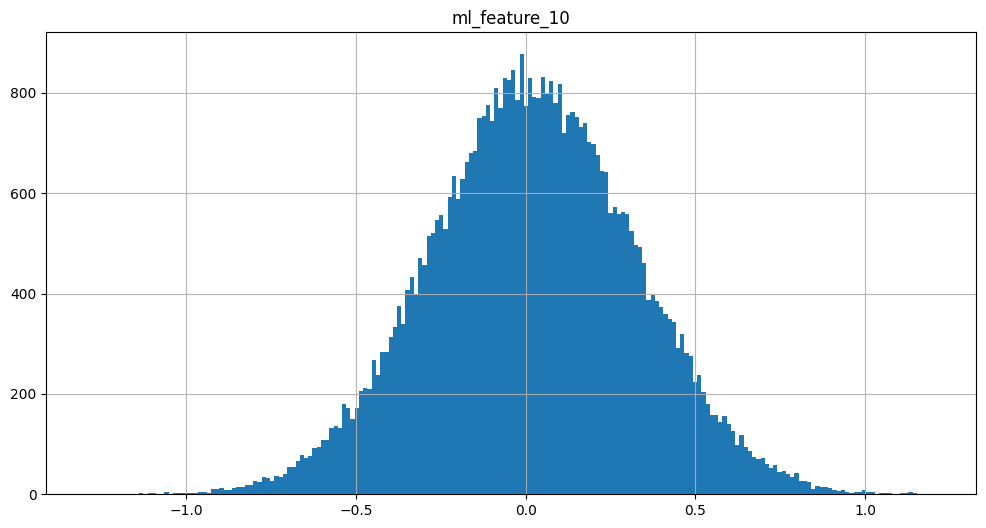

In [15]:
for feature in ['C15', 'C16', 'ml_feature_10']:
    plt.figure(figsize=(12, 6))
    df[feature].hist(bins=200)
    plt.title(feature)
    plt.xlabel(None)
    plt.grid(True, alpha=0.9)
    plt.show()

In [16]:
df['ml_feature_10'].describe()

count    50000.000000
mean         0.020226
std          0.303309
min         -1.287965
25%         -0.182386
50%          0.018930
75%          0.224080
max          1.202300
Name: ml_feature_10, dtype: float64

Стандартное отклонение 0.303 признака `ml_feature_10` достаточно большое, процентили показывают равномерное распределение.
Это полезный признак, который может давать информацию модели. Удалять его как квази-константный не стоит.

In [17]:
print(df['C15'].describe())

count    50000.00000
mean       318.86640
std         20.56153
min        120.00000
25%        320.00000
50%        320.00000
75%        320.00000
max       1024.00000
Name: C15, dtype: float64


In [18]:
print(f"Количество уникальных значений: {df['C15'].nunique()}")
print(f"Уникальные значения: {df['C15'].sort_values().unique()}")

Количество уникальных значений: 8
Уникальные значения: [ 120  216  300  320  480  728  768 1024]


In [19]:
c15_df = pd.DataFrame(df['C15'].value_counts().sort_values(ascending=False)).reset_index()
c15_df.columns = ['C15', 'count']
c15_df['rate'] = c15_df['count']/len(df)
display(c15_df)

,C15,count,rate
0,320,46787,0.93574
1,300,2758,0.05516
2,216,367,0.00734
3,728,78,0.00156
4,1024,5,0.00010
5,768,3,0.00006
6,480,1,0.00002
7,120,1,0.00002


Значения признака `C15` сосредоточены вокруг значений 320 и 300, остальные значения встречаются исчезающе редко. Признаем его квази-константным и удалим.

In [20]:
print(df['C16'].describe())

count    50000.000000
mean        59.692480
std         46.720842
min         20.000000
25%         50.000000
50%         50.000000
75%         50.000000
max       1024.000000
Name: C16, dtype: float64


In [21]:
print(f"Количество уникальных значений: {df['C16'].nunique()}")
print(f"Уникальные значения: {df['C16'].sort_values().unique()}")

Количество уникальных значений: 9
Уникальные значения: [  20   36   50   90  250  320  480  768 1024]


In [22]:
c16_df = pd.DataFrame(df['C16'].value_counts().sort_values(ascending=False)).reset_index()
c16_df.columns = ['C16', 'count']
c16_df['rate'] = c15_df['count']/len(df)
display(c16_df)

,C16,count,rate
0,50,47287,0.93574
1,250,2135,0.05516
2,36,367,0.00734
3,480,123,0.00156
4,90,78,0.00010
5,768,5,0.00006
6,1024,3,0.00002
7,320,1,0.00002
8,20,1,NaN


Значения признака `C16` принимают 3 дискретных значения: 50, 250 и 480, при этом значение 50 он принимает в 93,6% записей. Признаем его квази-константным и удалим.

In [23]:
# Квази-константные категориальные признаки:
quasi_cat_cols = [col for col in cat_features if df[col].value_counts(normalize=True).iloc[0] > 0.90]
print(quasi_cat_cols)

['C1', 'device_type']


In [24]:
for col in cat_features:
    most_frequent_ratio = df[col].value_counts().iloc[0] / len(df)
    if most_frequent_ratio > 0.9:
        print(f"{col}: {most_frequent_ratio:.2%} значений = {df[col].value_counts().index[0]}")

C1: 91.67% значений = 1005
device_type: 92.06% значений = 1


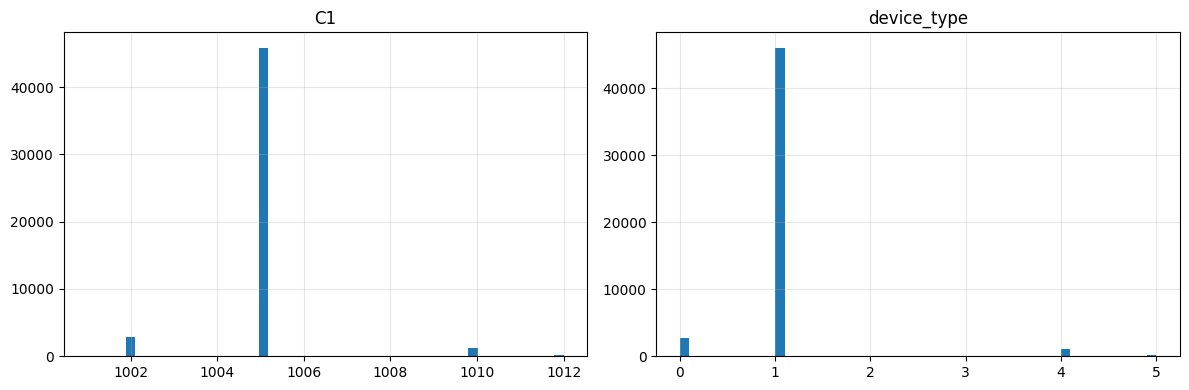

In [25]:
n_features = len(quasi_cat_cols)

n_cols = 2
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(quasi_cat_cols):
    df.hist(bins=50, column=feature, ax=axes[i])
    axes[i].set_title(feature)
    axes[i].grid(True, alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Несмотря на высокую долю наиболее частого значения для категориальных признаков `C1` и `device_type`, некоторая значимая вариативность в них присутствует, в сочетании с другими эти признаки могут коррелировать с целевой переменной, а также между собой - форма их графиков очень похожа, оставим их для дальнейшего анализа.

In [26]:
# Проверим датасет на ниличие идентичных признаков.
duplicated_columns = df.T.duplicated()
duplicates = df.columns[duplicated_columns].tolist()
if len(duplicates) == 0:
    print('Дублирующихся признаков в датасете не обнаружено.')
else:
    print("Дублирующиеся признаки:", duplicates)

Дублирующихся признаков в датасете не обнаружено.


In [27]:
# Удалим ненужные признаки.
features_to_drop += ['C15', 'C16']
num_features = list(set(num_features) - set(['C15', 'C16']))
df = df.drop(features_to_drop, axis=1)
print(f"Признаки {features_to_drop} удалены.")

Признаки ['app_id', 'id', 'device_id', 'device_ip', 'site_id', 'hour', 'hour_of_day', 'C15', 'C16'] удалены.


In [28]:
nulls = df.isnull().sum()
nulls_nonzero = nulls[nulls > 0]
if len(nulls_nonzero) > 0:
    print(nulls_nonzero)
else:
    print("Пропуски в датасете отсутствуют.")

Пропуски в датасете отсутствуют.


In [29]:
# Определим количество уникальных значений в каждом категориальном признаке.
encoded_features = df[cat_features].nunique()
print(encoded_features)

click                  2
C1                     7
banner_pos             7
site_category         18
site_domain         1013
app_domain            67
app_category          22
device_model        2521
device_type            4
device_conn_type       4
ml_feature_2           5
ml_feature_7           3
times_of_day           4
day_of_week            7
dtype: int64


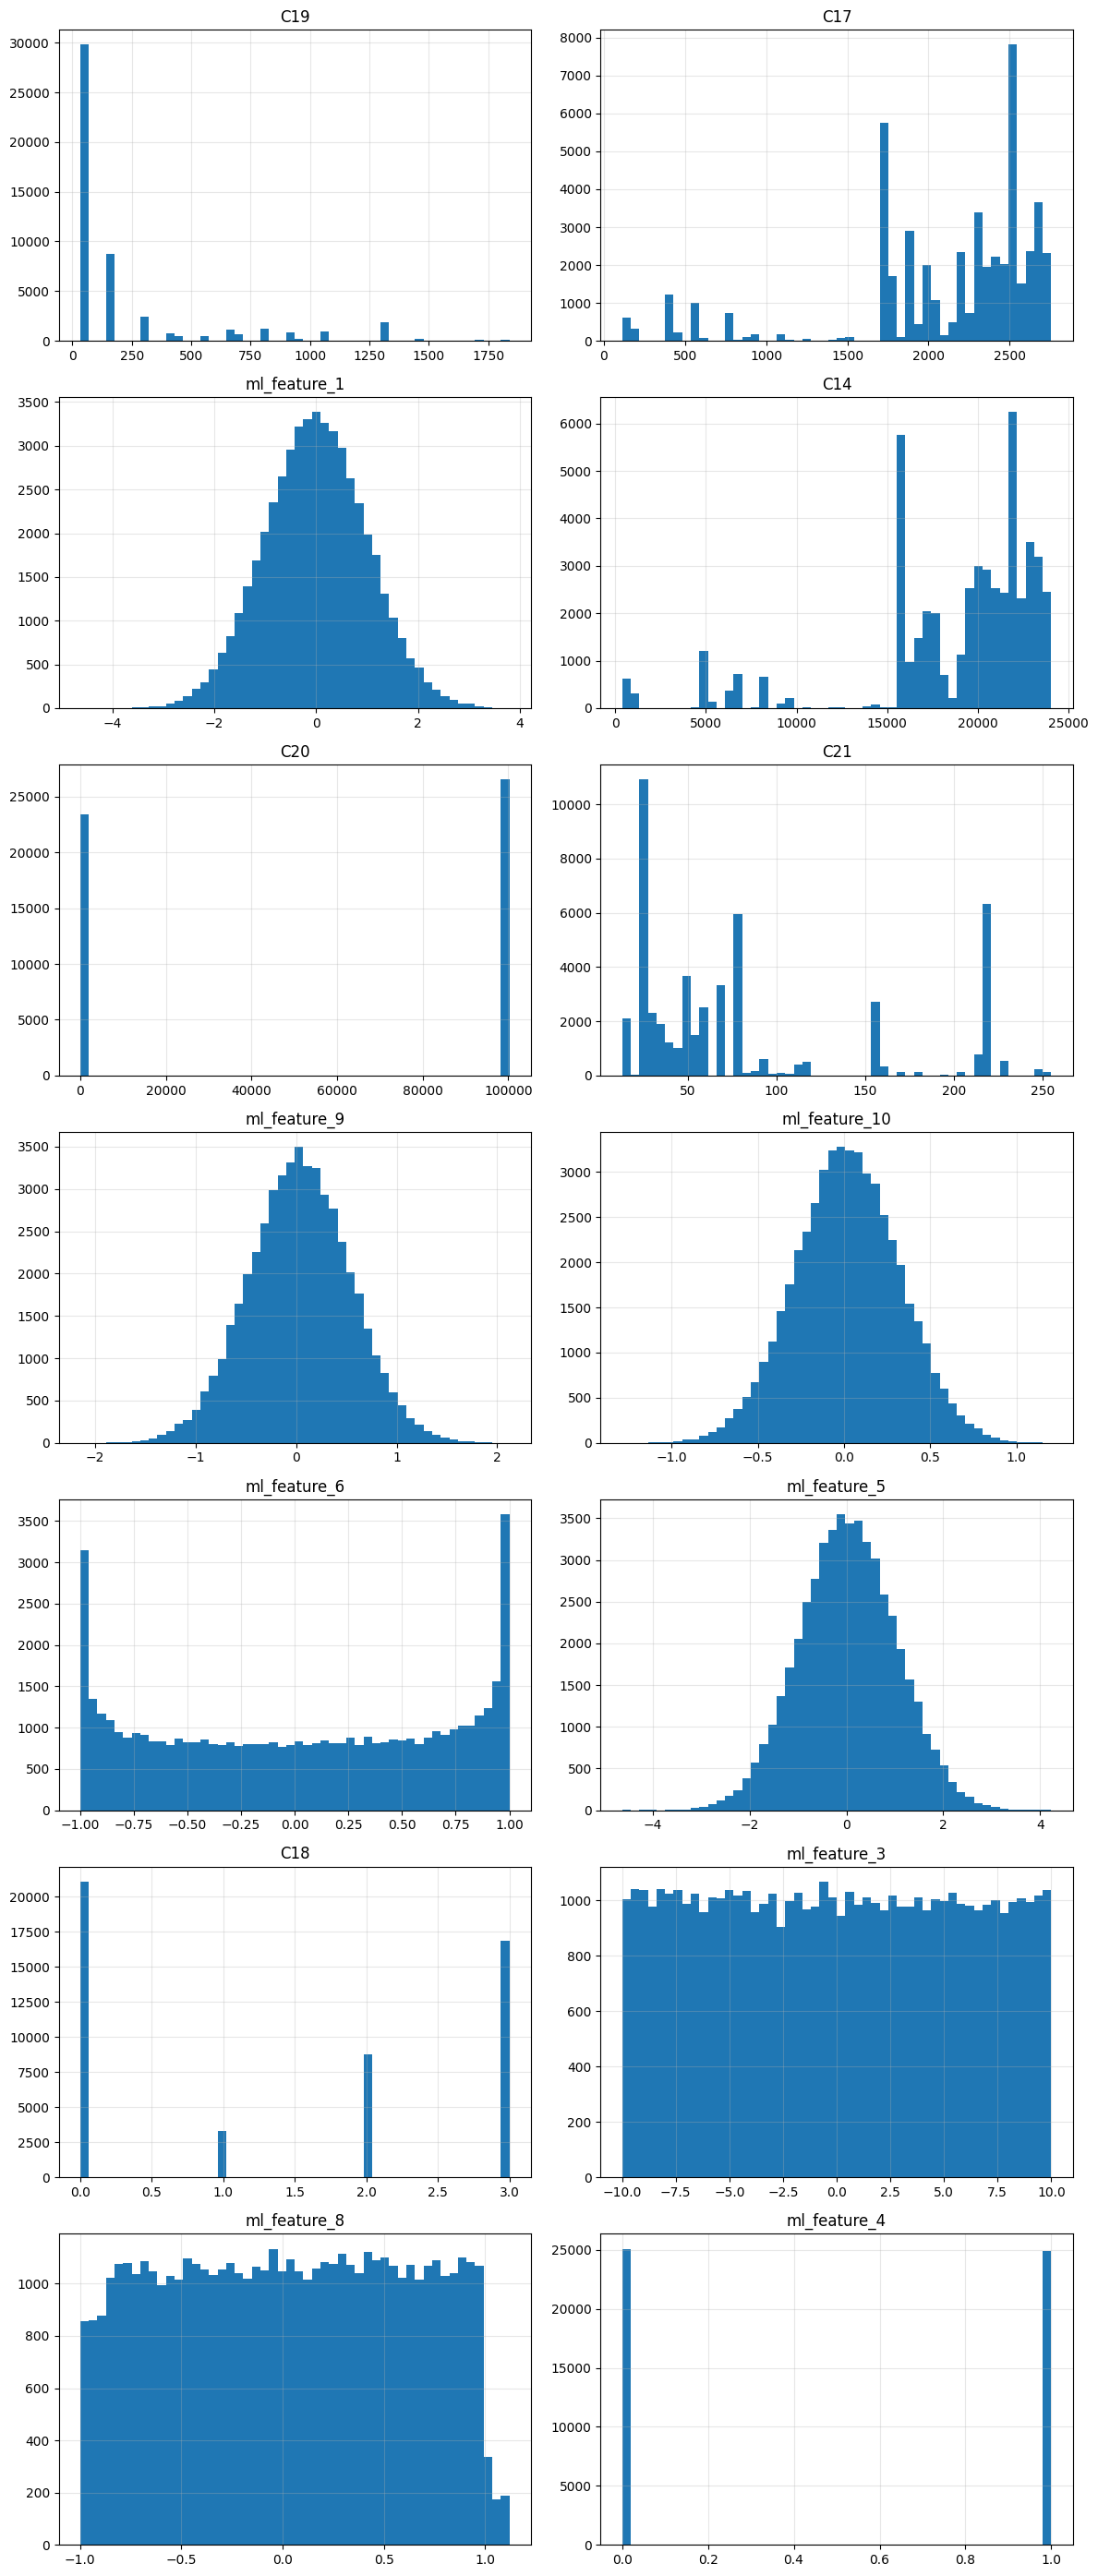

In [30]:
n_features = len(num_features)

n_cols = 2
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(num_features):
    df.hist(bins=50, column=feature, ax=axes[i])
    axes[i].set_title(feature)
    axes[i].grid(True, alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Признак `C18` может являться категориальными, а не числовым. Визуализируем его относительно целевой переменной: если тренд монотонный - признак числовой, если хаотичный - категориальный.

<BarContainer object of 4 artists>

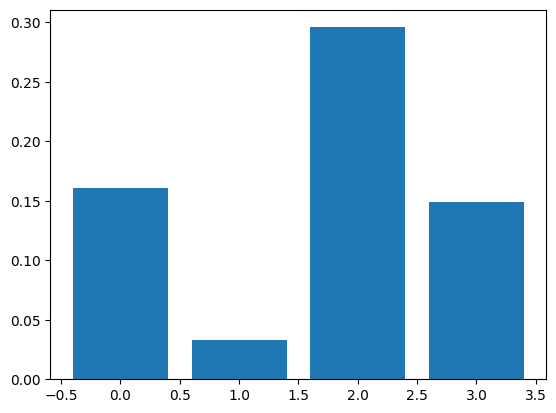

In [31]:
means = df.groupby('C18')['click'].mean()
plt.bar(means.index, means.values)

Признак `C18` верно принят числовым.\
\
Признак `ml_feature_4` также проявляет явные признаки категориального, но в описании датасета явно обозначен как числовой.

Проверим числовые признаки `C14` и `ml_feature_6` на наличие явных выбросов.

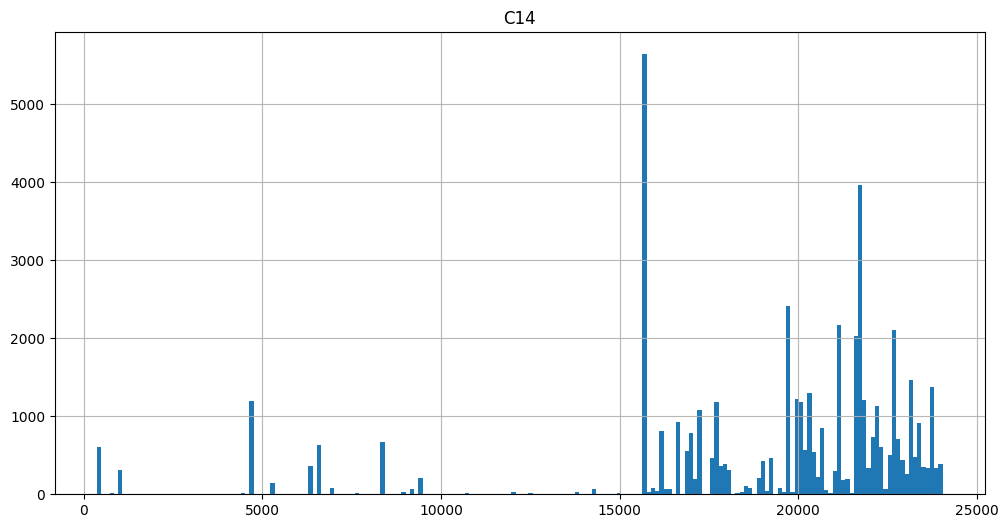

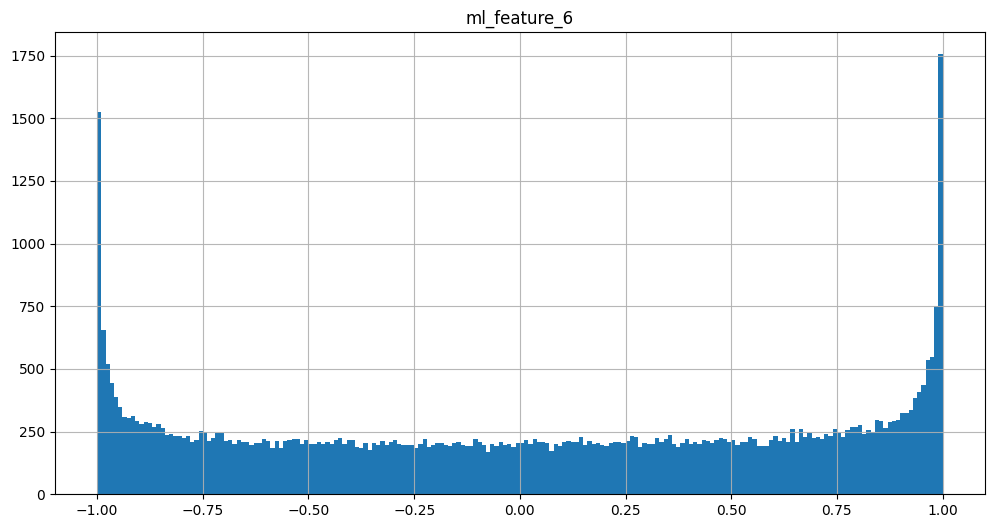

In [32]:
for feature in ['C14', 'ml_feature_6']:
    plt.figure(figsize=(12, 6))
    df[feature].hist(bins=200)
    plt.title(feature)
    plt.xlabel(None)
    plt.grid(True, alpha=0.9)
    plt.show()

Признак `ml_feature_6` имеет U-образную форму распределения, наибольшая плотность данных сосредоточена у экстремальных значений (-1 и 1). Распределение выглядит симметричным относительно центра. Для машинного обучения такой признак может быть очень полезным, так как он фактически разделяет объекты на две полярные группы, а экстремальные значения выбросами не являются.

In [33]:
print(f"Количество уникальных значений: {df['C14'].nunique()}")
print(f"Уникальные значения: {df['C14'].sort_values().unique()}")

Количество уникальных значений: 1497
Уникальные значения: [  375   377   380 ... 24041 24042 24043]


На графике признака `C14` представлено мультимодальное распределение с ярко выраженной дискретностью: видно множество отдельных «пиков» (мод), данные группируются вокруг определенных конкретных значений. Признак имеет дискретный характер, выбросов не обнаружено.

Прочие признаки распределены следующим образом:\
`hour` - мультимодальное распределение с выраженной дискретностью;\
`C17` - мультимодальное распределение;\
`C18` - мультимодальное распределение с выраженной дискретностью;\
`C19` - скошенное правостороннее распределение;\
`C20` - бимодальное распределение;\
`C21` - мультимодальное распределение;\
`ml_feature_1` - нормальное распределение;\
`ml_feature_3` - равномерное распределение;\
`ml_feature_4` - бинарное распределение;\
`ml_feature_5` - нормальное распределение;\
`ml_feature_8` - равномерное распределение;\
`ml_feature_9` - нормальное распределение;\
`ml_feature_10` - нормальное распределение.

Признак `C19` показывает пуассоновское распределение с большим правым хвостом. Можно убедить модель не обращать слишком большого внимания на слишком высокие значения и подтянуть их к центру распределения, добавив на этапе предобработки новый признак `log_C19` как логарифм с защитой от 0 признака `C19`.

In [34]:
# Оценим корреляцию признаков с целевой переменной с помощью коэффициента phik
phik_corr_matrix = df.phik_matrix(interval_cols=num_features)
phik_with_target = phik_corr_matrix['click'].sort_values(ascending=False)
print("\nКорреляция признака с целевой переменной:")
print(phik_with_target)

C:\Users\Peter\AppData\Roaming\Python\Python313\site-packages\phik\data_quality.py:59: UserWarning: The number of unique values of variable device_model is large: 2521. Are you sure this is not an interval variable? Analysis for pairs of variables including device_model can be slow.
  warnings.warn(
C:\Users\Peter\AppData\Roaming\Python\Python313\site-packages\phik\data_quality.py:59: UserWarning: The number of unique values of variable site_domain is large: 1013. Are you sure this is not an interval variable? Analysis for pairs of variables including site_domain can be slow.
  warnings.warn(



Корреляция признака с целевой переменной:
click               1.000000
site_domain         0.320956
C18                 0.257840
device_model        0.219222
ml_feature_9        0.187801
ml_feature_10       0.169983
C21                 0.166235
app_domain          0.161289
app_category        0.156537
site_category       0.155008
ml_feature_8        0.153598
device_conn_type    0.129954
C14                 0.112890
ml_feature_6        0.091314
C17                 0.091306
C19                 0.084697
ml_feature_5        0.080014
C20                 0.075979
device_type         0.071790
C1                  0.045931
day_of_week         0.023481
ml_feature_7        0.022622
banner_pos          0.022605
times_of_day        0.018708
ml_feature_1        0.010056
ml_feature_2        0.003790
ml_feature_3        0.000000
ml_feature_4        0.000000
Name: click, dtype: float64


С целевой переменной не коррелириуют признаки `ml_feature_3`, `ml_feature_4`, а также почти не коррелирует `ml_feature_2`. Оставим признаки с коэффициентом корреляции phik не менее 0.01.

In [35]:
# Выбираем признаки с phik > 0.01
selected_features = phik_with_target[phik_with_target > 0.01].index.tolist()
selected_features.remove('click')
print("Признаки, выбранные по phik:", selected_features)

Признаки, выбранные по phik: ['site_domain', 'C18', 'device_model', 'ml_feature_9', 'ml_feature_10', 'C21', 'app_domain', 'app_category', 'site_category', 'ml_feature_8', 'device_conn_type', 'C14', 'ml_feature_6', 'C17', 'C19', 'ml_feature_5', 'C20', 'device_type', 'C1', 'day_of_week', 'ml_feature_7', 'banner_pos', 'times_of_day', 'ml_feature_1']


In [36]:
# Находим пары сильно коррелирующих признаков
phik_selected_matrix = df[selected_features].phik_matrix(interval_cols=[f for f in selected_features if f in num_features])

high_corr_pairs = []
for i in range(len(phik_selected_matrix.columns)):
    for j in range(i+1, len(phik_selected_matrix.columns)):
        corr_value = phik_selected_matrix.iloc[i, j]
        if corr_value >= 0.9:
            high_corr_pairs.append((phik_selected_matrix.columns[i], phik_selected_matrix.columns[j], float(round(corr_value, 2))))

print("Сильно коррелирующие признаки (phik >= 0.9):")
print(high_corr_pairs)

C:\Users\Peter\AppData\Roaming\Python\Python313\site-packages\phik\data_quality.py:59: UserWarning: The number of unique values of variable device_model is large: 2521. Are you sure this is not an interval variable? Analysis for pairs of variables including device_model can be slow.
  warnings.warn(
C:\Users\Peter\AppData\Roaming\Python\Python313\site-packages\phik\data_quality.py:59: UserWarning: The number of unique values of variable site_domain is large: 1013. Are you sure this is not an interval variable? Analysis for pairs of variables including site_domain can be slow.
  warnings.warn(


Сильно коррелирующие признаки (phik >= 0.9):
[('site_domain', 'device_model', 1.0), ('site_domain', 'site_category', 0.99), ('site_domain', 'banner_pos', 0.92), ('device_model', 'app_domain', 0.99), ('device_model', 'app_category', 0.9), ('device_model', 'device_conn_type', 0.96), ('device_model', 'device_type', 0.96), ('device_model', 'C1', 0.95), ('app_domain', 'app_category', 0.94), ('C14', 'C17', 0.99)]


C:\Users\Peter\AppData\Roaming\Python\Python313\site-packages\phik\data_quality.py:59: UserWarning: The number of unique values of variable device_model is large: 2521. Are you sure this is not an interval variable? Analysis for pairs of variables including device_model can be slow.
  warnings.warn(
C:\Users\Peter\AppData\Roaming\Python\Python313\site-packages\phik\data_quality.py:59: UserWarning: The number of unique values of variable site_domain is large: 1013. Are you sure this is not an interval variable? Analysis for pairs of variables including site_domain can be slow.
  warnings.warn(


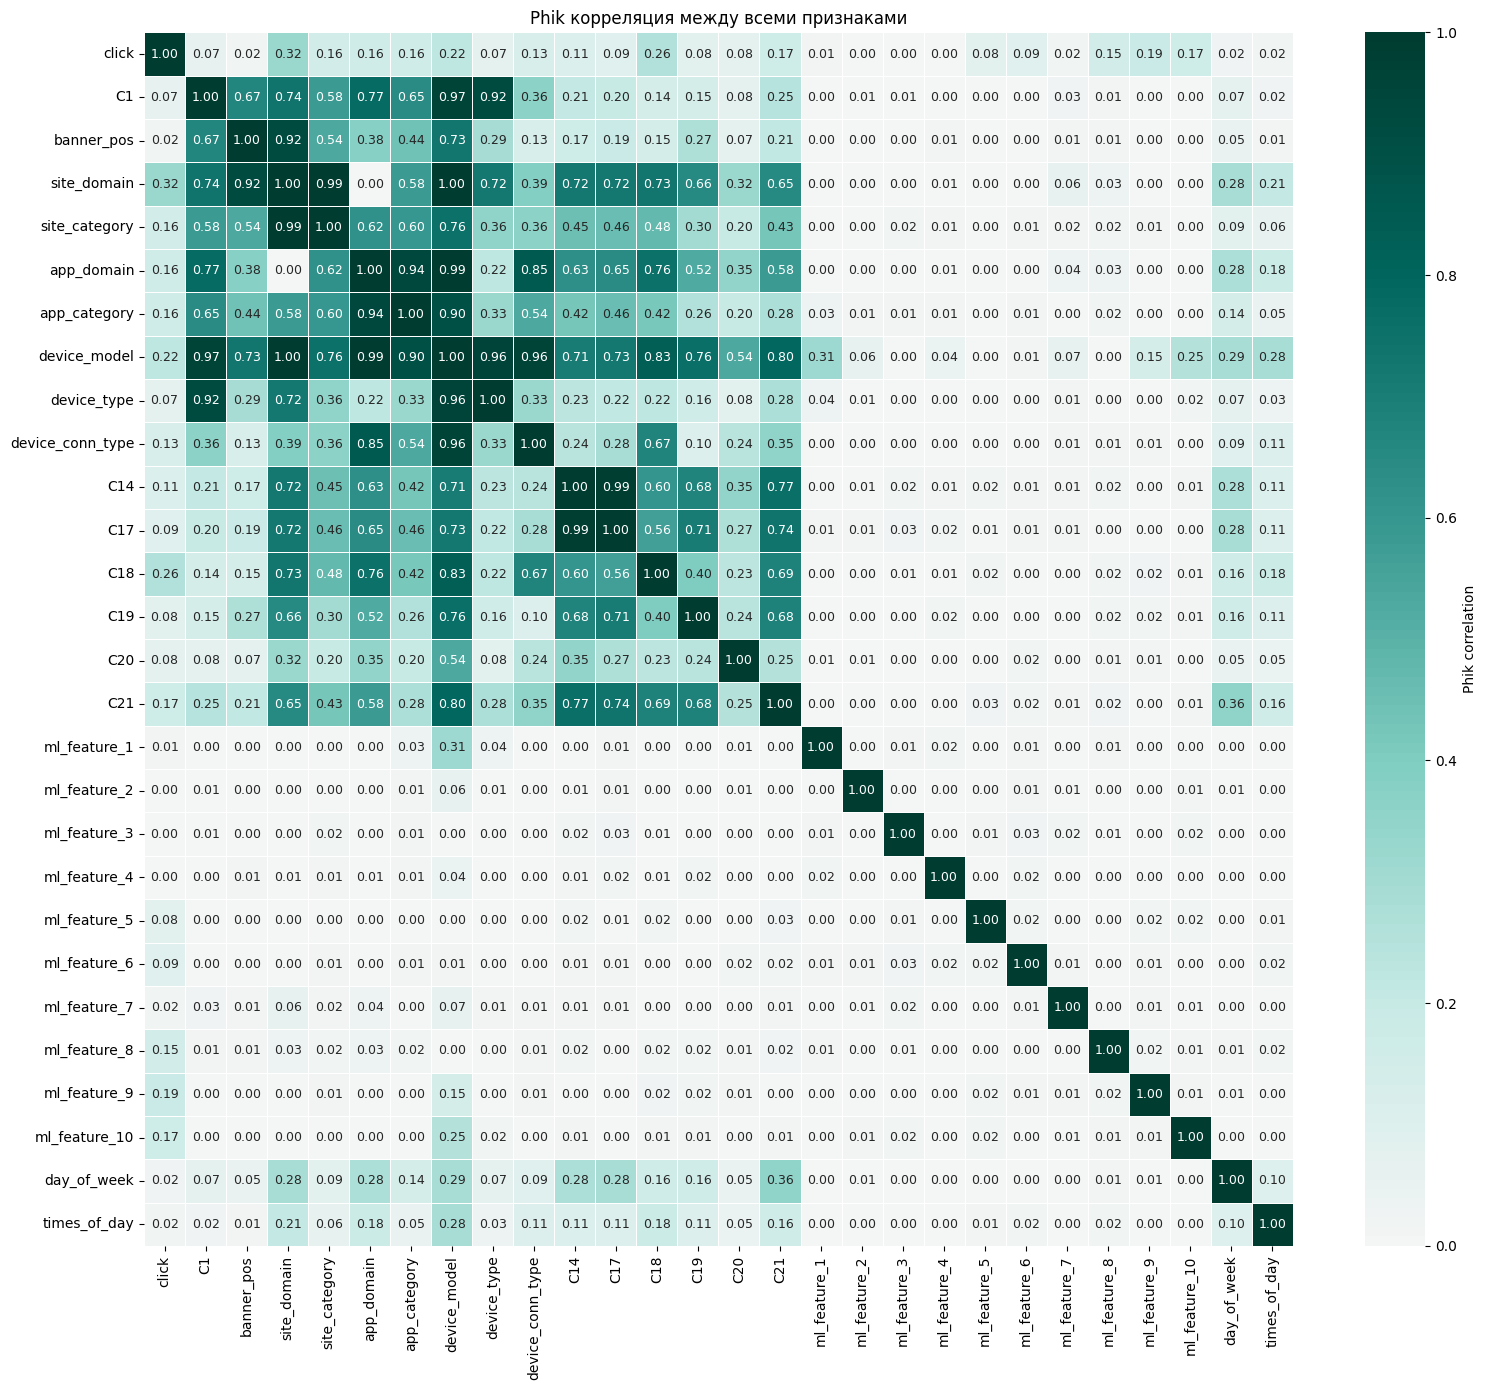

In [37]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
phik_matrix = df.phik_matrix(interval_cols=numeric_cols)

plt.figure(figsize=(16, 14)) 

sns.heatmap(
    phik_matrix, 
    cmap='BrBG', 
    center=0,
    xticklabels=True, 
    yticklabels=True,
    annot=True,                     
    fmt=".2f",                      
    annot_kws={"size": 9},          
    linewidths=0.5,
    cbar_kws={'label': 'Phik correlation'}
)

plt.title("Phik корреляция между всеми признаками")
plt.tight_layout()
plt.show()

Найдены очень сильно скоррелированные признаки, что говорит о дублировании информации (phik >= 0.9):
- ('site_domain', 'device_model', 1.0),
- ('site_domain', 'site_category', 0.99),
- ('site_domain', 'banner_pos', 0.92),
- ('device_model', 'app_domain', 0.99),
- ('device_model', 'app_category', 0.9),
- ('device_model', 'device_conn_type', 0.96),
- ('device_model', 'device_type', 0.96),
- ('device_model', 'C1', 0.95),
- ('app_domain', 'app_category', 0.94),
- ('C14', 'C17', 0.99)

Категориальные признаки `site_domain`, `device_model`, `app_domain`, `app_category` почти полностью дублируют друг друга.

Между числовыми признаками `C14`, `C17`, `C18`, `C19`, `C21` тоже есть сильная корреляция.    

Для уменьшения мультиколлинеарности можно оставить один признак из сильно коррелированных групп. Это позволит уменьшить переобучение и сократить вычислительные затраты.

Выберем наиболее информативные признаки по отношению к целевой переменной `click`, а коррелирующие между собой с меньшей связью удалим:
- оставлим `site_domain` как основной категориальный признак, удалим `device_model`, `site_category`, `app_domain`, `app_category`, `device_type`, `device_conn_type`;
- из числовых признаков наиболее информативными являются `C18`, `C21`, далее идёт `C14`, но он уже достаточно сильно коррелирует `C18` - оставим `C21` и `C18`, удалим `C14`, `C17`, `C19`.

Также из категориальных признаков удалим целевую переменную для дальнейшей работы с ними.

In [38]:
num_features = list(set(num_features) - set(['C14', 'C17', 'C19']))
cat_features = list(set(cat_features) - set(['device_model', 'site_category', 'app_domain', 'app_category', 'device_type', 'device_conn_type', 'click']))
print(f'Итоговые числовые признаки: {num_features}')
print(f'Итоговые категориальные признаки: {cat_features}')

Итоговые числовые признаки: ['ml_feature_1', 'ml_feature_10', 'C20', 'ml_feature_6', 'ml_feature_5', 'C18', 'C21', 'ml_feature_3', 'ml_feature_8', 'ml_feature_9', 'ml_feature_4']
Итоговые категориальные признаки: ['ml_feature_7', 'ml_feature_2', 'C1', 'site_domain', 'times_of_day', 'banner_pos', 'day_of_week']


In [39]:
df = df[num_features + cat_features + ['click']]
print("Размер итогового датасета:", df.shape)
display(df.head())

Размер итогового датасета: (50000, 19)


,ml_feature_1,ml_feature_10,C20,ml_feature_6,ml_feature_5,C18,C21,ml_feature_3,ml_feature_8,ml_feature_9,ml_feature_4,ml_feature_7,ml_feature_2,C1,site_domain,times_of_day,banner_pos,day_of_week,click
0,-0.996823,0.274038,-1,0.993275,0.817292,2,33,0.666588,-0.619959,0.433666,0,Z,A,1005,98572c79,night,1,1,1
1,-0.391309,-0.132851,-1,-0.825722,-0.883865,0,79,5.146789,0.576526,-0.318558,1,X,C,1005,f3845767,night,0,1,0
2,-2.112732,0.340487,100084,-0.338365,-0.859440,2,32,7.169348,-0.440047,-0.345412,0,Y,D,1005,98572c79,night,0,1,0
3,0.332707,-0.198542,100111,0.062934,0.062795,3,61,-0.290708,0.551982,0.733382,1,Y,A,1005,c4e18dd6,night,0,1,0
4,1.166623,-0.136909,100084,0.797144,-0.675276,0,79,6.319134,0.640827,0.297955,1,X,A,1005,f3845767,night,0,1,0


In [40]:
# Выделим признаки, которые можно кодировать методом One-Hot Encoding.
encoded_features = df[cat_features].nunique()
small_cat_features = encoded_features[encoded_features <=10].index.tolist()
print(small_cat_features)

['ml_feature_7', 'ml_feature_2', 'C1', 'times_of_day', 'banner_pos', 'day_of_week']


In [41]:
# Признаки, количество уникальных значений которых более 10, требуют специальных методов
# из-за высокой кардинальности, можем кодировать их методом Target Encoding.
big_cat_features = encoded_features[encoded_features > 10].index.tolist()
print(big_cat_features)

['site_domain']


### Выводы по EDA

В датасете содержится 50000 объектов и 34 признака. Признаки представлены числовым и категориальным типами данных.
Данные не содержат полных дубликатов.
В целевой переменной `click` наблюдается дисбаланс классов - доля рекламы, на которую кликнули, составляет 17% от общего числа показов. Пропуски в датасете отсутствуют.

Дублирующихся признаков в датасете не обнаружено.

Принято решение удалить следующие признаки:\
- `app_id` и `id` как искусственные;\
- `device_id`, `device_ip`, `site_id` как избыточные;\
- `C15` и `C16` как квази-константные;\
- `device_model`, `site_category`, `app_domain`, `app_category`, `device_type`, `device_conn_type`, `C14`, `C17`, `C19` как сильно коррелирующие с другими признаками.

Выбросы не обнаружены: признаки с возможными выбросами удалены как квази-константные.

Список категориальных признаков с числом категорий до 10 (для последующего кодирования методом One-Hot Encoding) собран в `small_cat_features`.\
Список категориальных признаков с числом категорий свыше 10 (для последующего кодирования методом Target Encoding) собран в `big_cat_features`.\
Список числовых признаков для последующей нормализации собран в `num_features`.

Признаками, которые выглядят наиболее перспективными для модели, являются `site_domain`, `C18` и `device_model` - они лучше остальных коррелируют с целевой переменной.

## Разделение данных на выборки

- Отделим тестовую выборку, в ней должно быть 20% данных, оставшиеся 80% данных используем для обучения: разделим их в соотношении 3 к 1 на тренировочную и калибровочную выборки.
- Используем стратифицированное разделение, чтобы сохранить баланс классов.
- Убедимся, что распределение целевой переменной сохранено в каждой выборке.

In [42]:
# Также для последующей калибровки вероятностей выделим калибровочную выборку
X = df.drop('click', axis=1)
y = df['click']
X_train_main, X_test, y_train_main, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=RANDOM_STATE)
X_train, X_cal, y_train, y_cal = train_test_split(X_train_main, y_train_main, test_size=0.25, shuffle=True, random_state=RANDOM_STATE)

In [43]:
X_train.shape

(30000, 18)

In [44]:
X_test.shape

(10000, 18)

In [45]:
X_cal.shape

(10000, 18)

In [46]:
y_train.shape

(30000,)

In [47]:
y_cal.shape

(10000,)

In [48]:
print("\n === Распределение целевой переменной ===\n")
print("Обучающая выборка:")
print(y_train.value_counts(normalize=True))
print("\nТестовая выборка:")
print(y_test.value_counts(normalize=True))


 === Распределение целевой переменной ===

Обучающая выборка:
click
0    0.828
1    0.172
Name: proportion, dtype: float64

Тестовая выборка:
click
0    0.8292
1    0.1708
Name: proportion, dtype: float64


## Предобработка данных — построение пайплайнов

Создадим пайплайн предобработки данных.

In [49]:
# Пайплайн для числовых признаков
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # заполняем пропуски медианой
    ('scaler', StandardScaler())                    # масштабируем
])
# Пайплайны для категориальных признаков
small_cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),  # заполняем пропуски заглушкой "missing"
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) # кодируем методом One Hot Encoding
])

big_cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),  # заполняем пропуски заглушкой "missing"
    ('targ_enc', TargetEncoder(random_state=RANDOM_STATE))                  # кодируем методом Target Encoding
])

# Объединяем с помощью ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', num_transformer, num_features),
    ('small_cat', small_cat_transformer, small_cat_features),
    ('big_cat', big_cat_transformer, big_cat_features)
])

# Создаём финальный пайплайн
pipeline = Pipeline([
    ('preprocessor', preprocessor)
])

## Отбор признаков

Определим порог корреляции признаков с целевой переменной, при котором их удаление приводит к улучшению метрик модели.

In [50]:
scoring = {
    'pr_auc': 'average_precision',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [51]:
for threshold in [0, 0.001, 0.01, 0.1]:
    filter_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('variance', VarianceThreshold(threshold=threshold)),
        ('select', SelectKBest(score_func=f_classif, k='all')),  
        ('classifier', LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE,
            class_weight='balanced'
        ))
    ])
    
    filter_scores = cross_validate(
        filter_pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring
    )
    
    print(f"Filter model results (threshold = {threshold}):")
    print("PR-AUC:", filter_scores['test_pr_auc'].mean().round(4))
    print("Precision:", filter_scores['test_precision'].mean().round(4))
    print("Recall:", filter_scores['test_recall'].mean().round(4))
    print("F1:", filter_scores['test_f1'].mean().round(4), "\n")

Filter model results (threshold = 0):
PR-AUC: 0.3695
Precision: 0.2944
Recall: 0.6421
F1: 0.4037 

Filter model results (threshold = 0.001):
PR-AUC: 0.3696
Precision: 0.2942
Recall: 0.6413
F1: 0.4034 

Filter model results (threshold = 0.01):
PR-AUC: 0.3696
Precision: 0.2943
Recall: 0.6411
F1: 0.4034 

Filter model results (threshold = 0.1):
PR-AUC: 0.313
Precision: 0.2599
Recall: 0.6269
F1: 0.3675 



Применение фильтрационных методов (SelectKBest) не приводит к улучшению качества модели, наилучший результат достигается при использовании всех признаков без дополнительной фильтрации.

Используем методы-обёртки для поиска оптимального набора признаков.

In [52]:
X_transformed = preprocessor.fit_transform(X_train, y_train)
print(f"Всего признаков на входе в модель: {X_transformed.shape[1]}")

Всего признаков на входе в модель: 45


In [53]:
for n_features in [None] + [10] + list(range(30, 43)):
    rfe_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('rfe', RFE(estimator=LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE,
            class_weight='balanced'
        ), n_features_to_select=n_features)),
        ('classifier', LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE,
            class_weight='balanced'
        ))
    ])

    rfe_scores = cross_validate(
        rfe_pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring
    )
    
    print(f"RFE model results (n_features = {n_features}):")
    print("PR-AUC:", rfe_scores['test_pr_auc'].mean().round(4))
    print("Precision:", rfe_scores['test_precision'].mean().round(4))
    print("Recall:", rfe_scores['test_recall'].mean().round(4))
    print("F1:", rfe_scores['test_f1'].mean().round(4), "\n")

RFE model results (n_features = None):
PR-AUC: 0.3687
Precision: 0.2936
Recall: 0.6403
F1: 0.4026 

RFE model results (n_features = 10):
PR-AUC: 0.3477
Precision: 0.2852
Recall: 0.6271
F1: 0.392 

RFE model results (n_features = 30):
PR-AUC: 0.3696
Precision: 0.295
Recall: 0.6442
F1: 0.4047 

RFE model results (n_features = 31):
PR-AUC: 0.3694
Precision: 0.295
Recall: 0.6446
F1: 0.4048 

RFE model results (n_features = 32):
PR-AUC: 0.3695
Precision: 0.2947
Recall: 0.6436
F1: 0.4043 

RFE model results (n_features = 33):
PR-AUC: 0.3698
Precision: 0.2949
Recall: 0.644
F1: 0.4045 

RFE model results (n_features = 34):
PR-AUC: 0.3698
Precision: 0.2949
Recall: 0.644
F1: 0.4045 

RFE model results (n_features = 35):
PR-AUC: 0.3697
Precision: 0.2945
Recall: 0.6426
F1: 0.4039 

RFE model results (n_features = 36):
PR-AUC: 0.3698
Precision: 0.295
Recall: 0.6434
F1: 0.4045 

RFE model results (n_features = 37):
PR-AUC: 0.3698
Precision: 0.2952
Recall: 0.6444
F1: 0.4049 

RFE model results (n_fea

Оптимальное количество признаков примем 37.\
При использовании метода RFE метрика PR-AUC чуть лучше, чем при фильтрации по пороговому значению, потому что она учитывает взаимное влияние признаков.

Выберем финальный набор признаков.

In [54]:
n_features = 37

rfe_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('rfe', RFE(estimator=LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE,
            class_weight='balanced'
        ), n_features_to_select=n_features)),
        ('classifier', LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE,
            class_weight='balanced'
        ))
    ])

rfe_pipeline.fit(X_train, y_train)

rfe_mask = rfe_pipeline.named_steps['rfe'].get_support()
all_feature_names = rfe_pipeline.named_steps['preprocessor'].get_feature_names_out()
selected_features_rfe = all_feature_names[rfe_mask]

print("Признаки, выбранные RFE:\n")
print(selected_features_rfe)

Признаки, выбранные RFE:

['num__ml_feature_10' 'num__C20' 'num__ml_feature_6' 'num__ml_feature_5'
 'num__C18' 'num__C21' 'num__ml_feature_8' 'num__ml_feature_9'
 'small_cat__ml_feature_7_X' 'small_cat__ml_feature_7_Y'
 'small_cat__ml_feature_7_Z' 'small_cat__ml_feature_2_A'
 'small_cat__ml_feature_2_B' 'small_cat__ml_feature_2_C'
 'small_cat__ml_feature_2_D' 'small_cat__ml_feature_2_E'
 'small_cat__C1_1001' 'small_cat__C1_1002' 'small_cat__C1_1005'
 'small_cat__C1_1007' 'small_cat__C1_1008' 'small_cat__C1_1010'
 'small_cat__times_of_day_evening' 'small_cat__times_of_day_morning'
 'small_cat__banner_pos_0' 'small_cat__banner_pos_1'
 'small_cat__banner_pos_2' 'small_cat__banner_pos_3'
 'small_cat__banner_pos_4' 'small_cat__banner_pos_5'
 'small_cat__banner_pos_7' 'small_cat__day_of_week_0'
 'small_cat__day_of_week_1' 'small_cat__day_of_week_2'
 'small_cat__day_of_week_4' 'small_cat__day_of_week_6'
 'big_cat__site_domain']


In [55]:
selected_indices = np.where(rfe_mask)[0]
print(selected_indices)

[ 1  2  3  4  5  6  8  9 11 12 13 14 15 16 17 18 19 20 21 22 23 24 27 28
 30 31 32 33 34 35 36 37 38 39 41 43 44]


In [56]:
# Создаём кастомный фильтр признаков
features_filter = ColumnTransformer([
    ('select', 'passthrough', selected_indices)
], remainder='drop')

In [57]:
# Финальный pipeline
final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('features_filter', features_filter),
    ('classifier', LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
        class_weight='balanced'
    ))
])

# Кросс-валидация финальной версии
final_scores = cross_validate(
    final_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

print("Final model results:")
print("PR-AUC:", final_scores['test_pr_auc'].mean().round(4))
print("Precision:", final_scores['test_precision'].mean().round(4))
print("Recall:", final_scores['test_recall'].mean().round(4))
print("F1:", final_scores['test_f1'].mean().round(4))

Final model results:
PR-AUC: 0.3699
Precision: 0.2959
Recall: 0.6455
F1: 0.4057


## Обучение базовой модели

Обучим базовую модель, LogisticRegression, SVC и сравним их.

In [58]:
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

pr_auc_scorer = make_scorer(average_precision_score)
pr_auc_scores = cross_val_score(dummy, X_train, y_train, cv=cv, scoring=pr_auc_scorer)

print("DummyClassifier baseline PR-AUC:", np.mean(pr_auc_scores).round(4))

DummyClassifier baseline PR-AUC: 0.172


In [59]:
logreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_filter', features_filter),
    ('classifier', LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
        class_weight='balanced'
    ))
])

scoring = {
    'pr_auc': 'average_precision',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

logreg_scores = cross_validate(
    logreg_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

print("LogisticRegression:")
print("PR-AUC:", logreg_scores['test_pr_auc'].mean().round(4))
print("Precision:", logreg_scores['test_precision'].mean().round(4))
print("Recall:", logreg_scores['test_recall'].mean().round(4))
print("F1:", logreg_scores['test_f1'].mean().round(4))

LogisticRegression:
PR-AUC: 0.3699
Precision: 0.2959
Recall: 0.6455
F1: 0.4057


Метрика PR-AUC модели LogisticRegression - 0.3699, базовой модели - 0.172, значит модель обучается.

In [60]:
svc_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_filter', features_filter),
    ('classifier', SVC(kernel='linear',
                       probability=False,
                       class_weight='balanced'))
])

svc_scores = cross_validate(
    svc_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

print("SVC (linear):")
print("PR-AUC:", svc_scores['test_pr_auc'].mean().round(4))
print("Precision:", svc_scores['test_precision'].mean().round(4))
print("Recall:", svc_scores['test_recall'].mean().round(4))
print("F1:", svc_scores['test_f1'].mean().round(4))

SVC (linear):
PR-AUC: 0.369
Precision: 0.2968
Recall: 0.6331
F1: 0.4041


Сравним модели по метрике PR-AUC, т.к. в целевой переменной сильный дисбаланс классов.\
Dummy - 0.172\
LogisticRegression - 0.3699\
SVC - 0.369

LogisticRegression немного лучше SVC.

## 7. Подбор гиперпараметров: Grid Search с кросс-валидацией

Переберём ключевые параметры, которые влияют на качество моделей `LogisticRegression` и `SVC`.

In [61]:
logreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_filter', features_filter),
    ('classifier', LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
        class_weight='balanced'
    ))
])

param_grid_logreg = {
    'classifier__C': [0.001, 0.01, 0.1, 1],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['liblinear', 'saga']
}

grid_logreg = GridSearchCV(
    estimator=logreg_pipeline,
    param_grid=param_grid_logreg,
    scoring='average_precision',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_logreg.fit(X_train, y_train)

print("=== LogisticRegression ===")
print("Лучшие параметры:", grid_logreg.best_params_)
print("Лучший PR-AUC:", grid_logreg.best_score_)

# Топ-10 конфигураций
logreg_results = pd.DataFrame(grid_logreg.cv_results_)
logreg_top10 = logreg_results[['params', 'mean_test_score']].sort_values(by='mean_test_score', ascending=False).head(10).reset_index(drop=True)
logreg_top10.index += 1

print("Топ-10 конфигураций LogisticRegression:")
with pd.option_context('display.max_colwidth', None):
    display(logreg_top10)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


C:\Users\Peter\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


=== LogisticRegression ===
Лучшие параметры: {'classifier__C': 0.1, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
Лучший PR-AUC: 0.3705456201578877
Топ-10 конфигураций LogisticRegression:


,params,mean_test_score
1,"{'classifier__C': 0.1, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}",0.370546
2,"{'classifier__C': 0.1, 'classifier__penalty': 'l1', 'classifier__solver': 'saga'}",0.370517
3,"{'classifier__C': 0.1, 'classifier__penalty': 'l2', 'classifier__solver': 'saga'}",0.370143
4,"{'classifier__C': 0.1, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}",0.370091
5,"{'classifier__C': 1, 'classifier__penalty': 'l2', 'classifier__solver': 'saga'}",0.369863
6,"{'classifier__C': 1, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}",0.369861
7,"{'classifier__C': 1, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}",0.369767
8,"{'classifier__C': 1, 'classifier__penalty': 'l1', 'classifier__solver': 'saga'}",0.369738
9,"{'classifier__C': 0.01, 'classifier__penalty': 'l1', 'classifier__solver': 'saga'}",0.368406
10,"{'classifier__C': 0.01, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}",0.365944


In [62]:
svc_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('feature_filter', features_filter),
    ('classifier', SVC(
        kernel='linear',
        probability=False,
        random_state=RANDOM_STATE,
    ))
])

param_grid_svc = {
    'classifier__C': [0.001, 0.01, 0.1, 1],
    'classifier__kernel': ['linear'],
    'classifier__class_weight': [None, 'balanced']
}

grid_svc = GridSearchCV(
    estimator=svc_pipeline,
    param_grid=param_grid_svc,
    scoring='average_precision',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_svc.fit(X_train, y_train)

print("\n=== SVC (Linear) ===")
print("Лучшие параметры:", grid_svc.best_params_)
print("Лучший PR-AUC:", grid_svc.best_score_)

# Топ конфигураций
svc_results = pd.DataFrame(grid_svc.cv_results_)
svc_top10 = svc_results[['params', 'mean_test_score']].sort_values(by='mean_test_score', ascending=False).head(10).reset_index(drop=True)
svc_top10.index += 1

print("Топ конфигураций SVC:")
with pd.option_context('display.max_colwidth', None):
    display(svc_top10)

Fitting 5 folds for each of 8 candidates, totalling 40 fits

=== SVC (Linear) ===
Лучшие параметры: {'classifier__C': 0.1, 'classifier__class_weight': 'balanced', 'classifier__kernel': 'linear'}
Лучший PR-AUC: 0.36908500412842704
Топ конфигураций SVC:


,params,mean_test_score
1,"{'classifier__C': 0.1, 'classifier__class_weight': 'balanced', 'classifier__kernel': 'linear'}",0.369085
2,"{'classifier__C': 1, 'classifier__class_weight': 'balanced', 'classifier__kernel': 'linear'}",0.368967
3,"{'classifier__C': 0.01, 'classifier__class_weight': 'balanced', 'classifier__kernel': 'linear'}",0.360353
4,"{'classifier__C': 0.001, 'classifier__class_weight': 'balanced', 'classifier__kernel': 'linear'}",0.327316
5,"{'classifier__C': 0.01, 'classifier__class_weight': None, 'classifier__kernel': 'linear'}",0.305783
6,"{'classifier__C': 0.001, 'classifier__class_weight': None, 'classifier__kernel': 'linear'}",0.302420
7,"{'classifier__C': 1, 'classifier__class_weight': None, 'classifier__kernel': 'linear'}",0.292941
8,"{'classifier__C': 0.1, 'classifier__class_weight': None, 'classifier__kernel': 'linear'}",0.291373


По результатам GridSearchCV лучшей моделью оказалась LogisticRegression со следующими параметрами:\
C=0.1,\
penalty='l1',\
solver='liblinear'.

Модель показала PR-AUC = 0.3705, что превосходит SVC (0.3691).
В качестве финальной модели выбираем линейный LogisticRegression.

## Финальная модель

Обучим финальную модель, используя лучшие параметры из Grid Search.

In [69]:
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_filter', features_filter),
    ('classifier', LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
        class_weight='balanced',
        C=0.1,
        penalty='l1',
        solver='liblinear'
    ))
])

final_pipeline.fit(X_train, y_train)

C:\Users\Peter\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('feature_filter', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('small_cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the 

In [82]:
# Делаем предсказания на тестовой выборке
y_pred_proba = final_pipeline.predict_proba(X_test)[:, 1]
y_pred = final_pipeline.predict(X_test)

pr_auc_final = average_precision_score(y_test, y_pred_proba)
brier_final = brier_score_loss(y_test, y_pred_proba)
precision_final = precision_score(y_test, y_pred)
recall_final = recall_score(y_test, y_pred)
f1_final = f1_score(y_test, y_pred)

print("\n=== Финальная модель: LogisticRegression ===\n")
print(f"    PR-AUC: {pr_auc_final:.4f}")
print(f"    Brier score: {brier_final:.4f}")
print(f"    Precision: {precision_final:.4f}")
print(f"    Recall: {recall_final:.4f}")
print(f"    F1-score: {f1_final:.4f}")


=== Финальная модель: LogisticRegression ===

    PR-AUC: 0.3853
    Brier score: 0.2066
    Precision: 0.3003
    Recall: 0.6464
    F1-score: 0.4101


In [71]:
coef = final_pipeline.named_steps['classifier'].coef_[0]
feature_names = selected_features_rfe  # признаки после RFE/фильтрации

feature_importance = pd.DataFrame({'feature': feature_names,
                                   'coef': coef,
                                   'abs_coef': np.abs(coef)}).sort_values(by='abs_coef', ascending=False).reset_index(drop=True)
feature_importance.index += 1

print("\n=== Самые важные признаки ===")
display(feature_importance.head(20))


=== Самые важные признаки ===


,feature,coef,abs_coef
1,big_cat__site_domain,4.910358,4.910358
2,small_cat__C1_1002,0.610542,0.610542
3,num__ml_feature_9,0.389222,0.389222
4,small_cat__C1_1010,-0.376871,0.376871
5,num__ml_feature_10,0.329795,0.329795
6,small_cat__ml_feature_7_Z,-0.214006,0.214006
7,num__ml_feature_8,0.203189,0.203189
8,num__ml_feature_6,0.181795,0.181795
9,small_cat__times_of_day_evening,-0.175683,0.175683
10,num__ml_feature_5,0.146060,0.146060


**Выводы по финальной модели LogisticRegression**

PR-AUC = 0.3853 — средний уровень качества для задачи с несбалансированными классами; модель лучше случайного предсказания, но есть пространство для улучшения.
Оценка Бриера = 0.2066 — модель в среднем хорошо калибрована, вероятности близки к истинным событиям.
Precision = 0.3003,
Recall = 0.6464,
F1-score = 0.4101.

Модель склонна давать больше ложноположительных предсказаний, но при этом уверенно предсказывает большую часть настоящих кликов (Recall > Precision).
Модель предсказывает клики с приемлемой чувствительностью.

Ключевой вклад дают категориальные признаки (в первую очередь `site_domain`) с высокой кардинальностью и некоторые числовые признаки, полученные в результате предварительной обработки и генерации новых признаков. Для повышения качества можно рассмотреть более сложные модели или сгенерировать дополнительные признаки, но текущая модель служит надежной базой и демонстрирует правильную работу пайплайна и предобработки.

\
**Вывод по важности признаков**

Наиболее сильное влияние на предсказание клика оказывает признак `site_domain` (коэффициент ≈ 4.63). Это логично, так как разные сайты могут иметь существенно разную конверсию.
Среди числовых признаков наибольшую значимость имеют `ml_feature_9`, `ml_feature_10` и `ml_feature_8`, их коэффициенты положительные, что указывает на прямую зависимость с вероятностью клика.
Остальные признаки, такие как ml_feature_5, ml_feature_6 и C21, также вносят вклад, но гораздо меньше.
Признаки C21 и C20 имеют отрицательные коэффициенты, что говорит о том, что при увеличении их значения вероятность клика снижается.

Вероятность клика также снижается в вечерние часы (times_of_day_evening).

Итог: модель корректно выделяет ключевой категориальный признак и несколько числовых, которые сильнее прочих связаны с целевой переменной. Это подтверждает правильность отбора признаков на этапах фильтрации и RFE.

## Калибровка модели

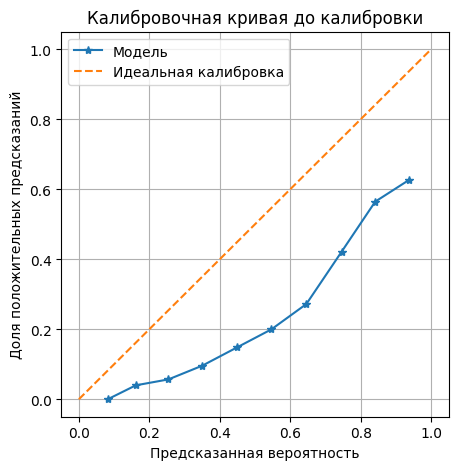

In [72]:
# Проверим текущую калибровку
y_pred_proba = final_pipeline.predict_proba(X_test)[:, 1]
prob_true, prob_pred = calibration_curve(y_test, y_pred_proba, n_bins=10, strategy='uniform')

plt.figure(figsize=(5,5))
plt.plot(prob_pred, prob_true, marker='*', label='Модель')
plt.plot([0,1], [0,1], linestyle='--', label='Идеальная калибровка')
plt.xlabel('Предсказанная вероятность')
plt.ylabel('Доля положительных предсказаний')
plt.title('Калибровочная кривая до калибровки')
plt.grid(True)
plt.legend()
plt.show()

C:\Users\Peter\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\Peter\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\Peter\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\Peter\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\Peter\AppData\Roaming\Python\Python313\site-packages\sklearn\li

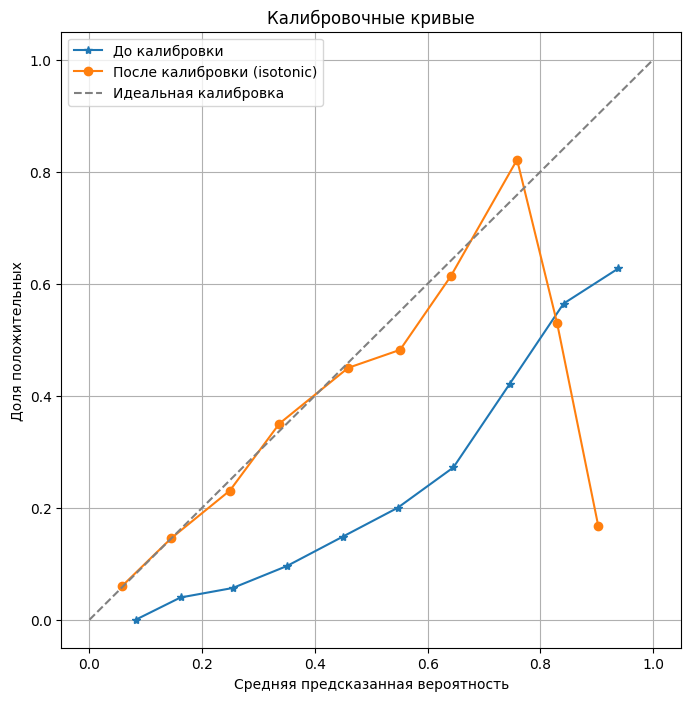

In [89]:
X_test_transformed = features_filter.transform(preprocessor.transform(X_test))
X_cal_transformed = features_filter.transform(preprocessor.transform(X_cal))

calibrated_model = CalibratedClassifierCV(
    estimator=final_pipeline.named_steps['classifier'],
    method='isotonic',
    cv=StratifiedKFold(n_splits=7, shuffle=True, random_state=RANDOM_STATE)
)
calibrated_model.fit(X_cal_transformed, y_cal)

y_pred_proba_uncal = final_pipeline.named_steps['classifier'].predict_proba(X_test_transformed)[:, 1]
y_pred_proba_cal = calibrated_model.predict_proba(X_test_transformed)[:, 1]
y_pred_cal = (y_pred_proba_cal >= 0.5).astype(int)

prob_true_uncal, prob_pred_uncal = calibration_curve(y_test, y_pred_proba_uncal, n_bins=10)
prob_true_cal, prob_pred_cal = calibration_curve(y_test, y_pred_proba_cal, n_bins=10)

plt.figure(figsize=(8, 8))
plt.plot(prob_pred_uncal, prob_true_uncal, marker='*', label='До калибровки')
plt.plot(prob_pred_cal, prob_true_cal, marker='o', label='После калибровки (isotonic)')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Идеальная калибровка')
plt.xlabel('Средняя предсказанная вероятность')
plt.ylabel('Доля положительных')
plt.title('Калибровочные кривые')
plt.legend()
plt.grid(True)
plt.show()

In [90]:
# Рассчитаем метрики до и после калибровки
pr_auc_uncal = average_precision_score(y_test, y_pred_proba_uncal)
pr_auc_cal = average_precision_score(y_test, y_pred_proba_cal)
brier_uncal = brier_score_loss(y_test, y_pred_proba_uncal)
brier_cal = brier_score_loss(y_test, y_pred_proba_cal)

precision_cal = precision_score(y_test, y_pred)
recall_cal = recall_score(y_test, y_pred)
f1_cal = f1_score(y_test, y_pred)

metrics = {
    "PR-AUC (Uncal)": pr_auc_uncal,
    "PR-AUC (Cal)": pr_auc_cal,    
    "Brier (Uncal)": brier_uncal,
    "Brier (Cal)": brier_cal
}

for metric, value in metrics.items():
    print(f"{metric:<25} | {value:.4f}")

def expected_calibration_error(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0
    mce = 0
    for i in range(n_bins):
        mask = (y_prob > bins[i]) & (y_prob <= bins[i + 1])
        if mask.any():
            p_true = y_true[mask].mean()
            p_pred = y_prob[mask].mean()
            ece += (mask.sum() / len(y_prob)) * abs(p_true - p_pred)
            mce = max(mce, abs(p_true - p_pred))
    return ece, mce

ece_uncal, mce_uncal = expected_calibration_error(y_test.values, y_pred_proba_uncal)
ece_cal, mce_cal = expected_calibration_error(y_test.values, y_pred_proba_cal)

print()
print("ECE до калибровки:", round(ece_uncal, 4), "| после калибровки:", round(ece_cal, 4))
print("MCE до калибровки:", round(mce_uncal, 4), "| после калибровки:", round(mce_cal, 4))

PR-AUC (Uncal)            | 0.3853
PR-AUC (Cal)              | 0.3839
Brier (Uncal)             | 0.2066
Brier (Cal)               | 0.1251

ECE до калибровки: 0.2775 | после калибровки: 0.0081
MCE до калибровки: 0.3737 | после калибровки: 0.7362


(array([3191., 3207., 1703., 1119.,  218.,  169.,  227.,  100.,   27.,
          39.]),
 array([0.        , 0.0902865 , 0.180573  , 0.2708595 , 0.361146  ,
        0.4514325 , 0.541719  , 0.63200549, 0.72229199, 0.81257849,
        0.90286499]),
 <BarContainer object of 10 artists>)

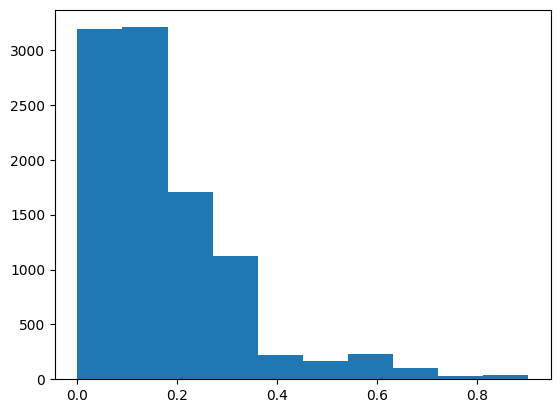

In [91]:
# Оценим распределение вероятностных предсказаний модели
plt.hist(y_pred_proba_cal, bins=10)

## Оценка качества калибровки

In [92]:
metrics_df = pd.DataFrame({
    "PR-AUC": [pr_auc_final, pr_auc_cal],
    "Brier score": [brier_final, brier_cal],
    "Precision": [precision_final, precision_cal],
    "Recall": [recall_final, recall_cal],
    "F1-score": [f1_final, f1_cal],
    "ECE": [ece_uncal, ece_cal],
    "MCE": [mce_uncal, mce_cal]
}, index=["До калибровки", "После калибровки"])

metrics_df

,PR-AUC,Brier score,Precision,Recall,F1-score,ECE,MCE
До калибровки,0.385333,0.206571,0.300326,0.64637,0.410104,0.277453,0.373721
После калибровки,0.383895,0.125139,0.300326,0.64637,0.410104,0.008140,0.736198


***Вывод по калибровке модели***

На графике и в метриках видно, что калибровка сработала точечно, но не смогла исправить главную проблему — обвал уверенности в правой части.

ECE (Expected Calibration Error) снизился: с 0.277453 до 0.008140, в среднем предсказания стали ближе к реальности.\
Brier Score существенно изменился: (0.206571 vs 0.125139), это указывает, что вероятности модели после калибровки стали гораздо точнее соответствовать фактическим событиям. Brier score учитывает и точность классификации, и калибровку.\
Так как PR-AUC немного просел, суммарная ошибка осталась той же.\
MCE (Maximum Calibration Error) вырос и стал достаточно большой: 0.736198.

Это связано с тем, что в наборе данных очень мало примеров с кликами, где модель была бы максимально уверена. Изотоническая регрессия попыталась сгладить этот участок, но из-за нехватки данных в калибровочной выборке она просто повторила ошибку базовой модели.\
Калибровка методом Isotonic улучшила среднюю ошибку (ECE), однако из-за малого количества объектов в области высокой уверенности модель сохраняет значительное отклонение от идеальной линии на хвостах распределения.

## 11. Финальный отчёт и выводы

In [98]:
final_report = pd.DataFrame({
    "PR-AUC": [
        np.mean(pr_auc_scores),   # Dummy
        pr_auc_final,             # До калибровки
        pr_auc_cal                # После калибровки
    ],
    "Brier score": [
        np.nan,
        brier_final,
        brier_cal
    ],
    "Precision": [
        np.nan,
        precision_final,
        precision_cal
    ],
    "Recall": [
        np.nan,
        recall_final,
        recall_cal
    ],
    "F1-score": [
        np.nan,
        f1_final,
        f1_cal
    ],
    "ECE": [
        np.nan,
        ece_uncal,
        ece_cal
    ],
    "MCE": [
        np.nan,
        mce_uncal,
        mce_cal
    ]
}, index=[
    "DummyClassifier",
    "LogisticRegression  (до калибровки)",
    "LogisticRegression  (после калибровки)"
])

display(final_report)

,PR-AUC,Brier score,Precision,Recall,F1-score,ECE,MCE
DummyClassifier,0.172000,NaN,NaN,NaN,NaN,NaN,NaN
LogisticRegression (до калибровки),0.385333,0.206571,0.300326,0.64637,0.410104,0.277453,0.373721
LogisticRegression (после калибровки),0.383895,0.125139,0.300326,0.64637,0.410104,0.008140,0.736198


In [94]:
top5_features = feature_importance[['feature', 'coef']].head(5)
display(top5_features)

,feature,coef
1,big_cat__site_domain,4.910358
2,small_cat__C1_1002,0.610542
3,num__ml_feature_9,0.389222
4,small_cat__C1_1010,-0.376871
5,num__ml_feature_10,0.329795


1. Качество модели по сравнению с базовой существенно улучшилось.
   
PR-AUC вырос с 0.172 до 0.3839, модель действительно научилась выделять клики. 

2. Признак, больше всего влияющий на вероятность клика, `site_domain`.

Это говорит о том, что тип сайта сильно влияет на вероятность клика, поведение пользователя зависит от контекста площадки.
Дополнительно влияют агрегированные ML-признаки `ml_feature_9`, `ml_feature_10` и `ml_feature_8`.
Также значение имеет время суток просмотра - вероятность клика снижается в вечерние часы.

2. Модель откалибрована не достаточно хорошо в области больших вероятностей, больший размер датасета позволил бы сделать это лучше, но в целом не плохо.
 
До калибровки:
* ECE = 0.277453 - не плохая общая калибровка,
* MCE = 0.373721 - модель сохраняет значительное отклонение от идеальной линии на вероятностях выше 0,8.

После калибровки:
* ECE = 0.008140 - общая калибровка достаточно точная,
* MCE = 0.736198 - в области больших вероятностей модель стала хуже.

Оценка Бриера значительно улучшилась.

Модель частично готова к продакшену, её можно использовать как базовое решение, но перед внедрением необходимо доработать.

Рекомендации по улучшению: оптимизация порога классификации, введение новых признаков, подбор оптимального соотношения обучающей, калибровочной и тестовой выборок. Также можно попробовать отобрать признаки другими методами-обертками.

## Сохранение модели для продакшена

Сохраним пайплайн предобработки данных, финальную модель и информацию о выбранных признаках.

In [95]:
joblib.dump(preprocessor, 'preprocessor.pkl') # сохраняем preprocessor
joblib.dump(calibrated_model, 'calibrated_model.pkl') # cохраняем финальную калиброванную модель 
joblib.dump(selected_features_rfe, 'selected_features.pkl') # cохраняем список выбранных признаков
print('Артефакты успешно сохранены.')

Артефакты успешно сохранены.


Проверим работоспособность кода.

In [96]:
# Загружаем артефакты
loaded_preprocessor = joblib.load('preprocessor.pkl')
loaded_model = joblib.load('calibrated_model.pkl')
loaded_features = joblib.load('selected_features.pkl')

print('Артефакты успешно загружены.')

Артефакты успешно загружены.


In [99]:
# Предскажем вероятности на новых данных
X_new = X_test.sample(n=10, random_state=RANDOM_STATE).copy()
X_new_transformed = loaded_preprocessor.transform(X_new)
X_new_filtered = features_filter.transform(X_new_transformed)

# --- Предсказание ---
new_proba = loaded_model.predict_proba(X_new_filtered)[:, 1]

print("Вероятности клика:")
print(new_proba)

Вероятности клика:
[0.33093273 0.17821417 0.07514323 0.18508982 0.01828474 0.15119162
 0.08605764 0.15119162 0.09179835 0.08128649]


In [101]:
# Проверим совпадение
original_proba = calibrated_model.predict_proba(
    features_filter.transform(preprocessor.transform(X_new))
)[:, 1]

print("Совпадают ли предсказания:",
      np.allclose(original_proba, new_proba))

Совпадают ли предсказания: True
